# NV-to-Lab-Frame Calibration: local response matrix, dip-pair assignment, and best-fit rotation

This notebook uses the fitted outputs from the previous Lorentzian ODMR fitting workflow to calibrate the **geometry** of the experiment before reconstructing the magnetic field itself.

## Experimental context
The experiment uses a **[100]-cut diamond** with four NV orientations, and a fully resolved **8-dip ODMR spectrum** with \(^{14}\mathrm{N}\) hyperfine structure. The sample is translated in small steps along the lab axes:
- **lab \(x\)**: approximately along the magnet–magnet line,
- **lab \(y\)**: the depth direction of the setup,
- **lab \(z\)**: the optical axis and surface normal of the diamond.

The previous notebook already fitted the ODMR data and paired the left/right dips. This notebook starts from those fitted pair splittings.

## Goal
We do **not** reconstruct \(\mathbf B\) yet.  
Instead, we determine:
1. an empirical **local response matrix** from the pair-splitting trends,
2. a best-fit **dip-pair \(\leftrightarrow\) NV-axis assignment**,
3. a best-fit **rotation matrix** from the diamond frame to the lab frame.

## Response matrix from the full displacement range

In this notebook, the measured response matrix is built from the **full displacement range** of each scan, not only from the points nearest the nominal origin.

The reason is experimental rather than purely mathematical: the reference point labeled \(0.0\ \mathrm{mm}\) is a practical measurement starting point, but it is not guaranteed to be a special symmetry point of the magnetic field. Therefore, using only a few points close to \(0\) can overemphasize noise or local irregularities.

For each measured dip pair \(p\) and scan direction \(a\in\{x,y,z\}\), we therefore fit a straight line
\[
\Delta f_p(\delta a)=b_{pa}+m_{pa}\,\delta a
\]
over the **entire available scan range**, and use the fitted slope
\[
m_{pa}=\frac{\partial \Delta f_p}{\partial a}
\]
as the empirical response coefficient.

This makes the response matrix a summary of the overall directional trend seen in the measured data. At the same time, we keep a local-fit diagnostic to reveal whether one scan direction—especially \(y\)—deviates from a simple linear picture. That nonlinearity is physically plausible in an NV magnetometry setup when the field changes appreciably over the scan range or contains strong off-axis components. 
## Core observable
For each measured dip pair \(p\), we use the fitted central-hyperfine splitting
\[
\Delta f_p = f_{p,+} - f_{p,-}.
\]

For small translations around the operating point,
\[
\mathbf B(\mathbf r_0+\delta\mathbf r)\approx \mathbf B_0 + G\,\delta\mathbf r.
\]

This motivates a **local linear response**
\[
\Delta f_p(\delta a)\approx \Delta f_{p,0} + m_{pa}\,\delta a,
\]
where \(a\in\{x,y,z\}\) and \(m_{pa}\) is the local slope of pair \(p\) along lab axis \(a\).

Collecting those slopes gives the measured response matrix
\[
M_{\mathrm{meas}}=
\begin{pmatrix}
m_{1x} & m_{1y} & m_{1z}\\
m_{2x} & m_{2y} & m_{2z}\\
m_{3x} & m_{3y} & m_{3z}\\
m_{4x} & m_{4y} & m_{4z}
\end{pmatrix}.
\]

## Why a local fit near the origin?
Your dataset shows that the trends along \(x\) and \(z\) are close to linear, while the trends along \(y\) show visible curvature. That is physically plausible:
- motion along **depth** can sample a more curved part of the magnet field,
- off-axis magnetic fields can produce nonlinear ODMR shifts,
- so a full-range straight-line fit can be a poor proxy for the true local derivative near the operating point.

For that reason, the geometric calibration below uses a **local near-origin slope fit**.

## Literature used
- Dennis Lönard et al., *Limits of absolute vector magnetometry with NV centers in diamond*.
- Pralekh Dubey et al., *Magnetic field orientation dependence of continuous-wave optically detected magnetic resonance with nitrogen-vacancy ensembles*.
- Timo Weggler et al., *Determination of the 3D Magnetic Field Vector Orientation with NV Centers in Diamond*.
- N. M. Beaver et al., *Optimizing Off-Axis Fields for Two-Axis Magnetometry with Nitrogen-Vacancy Centers*.

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from scipy.stats import linregress
from itertools import permutations, product
from scipy.optimize import minimize

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Data source

This notebook expects the previous fitting notebook to have written outputs into:

`../fitting_odmr/batch_fit_outputs_lorentzian`

with subfolders:
- `Variation Along X`
- `Variation Along Y`
- `Variation Along Z`

and one folder per displacement point, each containing:
- `paired_dips.csv`
- `fitted_dips.csv` (not used directly here)
- `fit_metadata.json` (optional here)

The main file used here is `paired_dips.csv`, because it already contains the fitted pair splittings.

In [99]:
ROOT = Path("../fitting_odmr/batch_fit_outputs_lorentzian")

VARIATION_TO_AXIS = {
    "Variation Along X": "x",
    "Variation Along Y": "y",
    "Variation Along Z": "z",
}

for variation in VARIATION_TO_AXIS:
    path = ROOT / variation
    print(f"{variation}: {'FOUND' if path.exists() else 'MISSING'} -> {path}")

Variation Along X: FOUND -> ../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along X
Variation Along Y: FOUND -> ../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Y
Variation Along Z: FOUND -> ../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Z


## Helper functions for loading the fitted pair data

In [100]:
def parse_offset_mm(name: str) -> float:
    name = name.strip().replace(" ", "")
    if name == "0cm":
        return 0.0

    m = re.search(r'([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))

    m = re.search(r'0cm([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))

    raise ValueError(f"Could not parse displacement from folder name: {name}")


def load_one_pair_file(pair_csv: Path, variation: str, run_name: str) -> pd.DataFrame:
    df = pd.read_csv(pair_csv).copy()

    df["variation"] = variation
    df["lab_axis"] = VARIATION_TO_AXIS[variation]
    df["run_name"] = run_name
    df["offset_mm"] = parse_offset_mm(run_name)

    required_cols = [
        "pair_id",
        "left_center_x1_GHz",
        "right_center_x1_GHz",
        "splitting_MHz",
        "pair_center_GHz",
        "pair_center_minus_D_eff_MHz",
        "D_eff_GHz",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {pair_csv}: {missing}")

    return df

## Load the full displacement dataset

In [101]:
all_pair_rows = []

for variation in VARIATION_TO_AXIS:
    variation_dir = ROOT / variation
    if not variation_dir.exists():
        print(f"Skipping missing folder: {variation_dir}")
        continue

    run_dirs = sorted([p for p in variation_dir.iterdir() if p.is_dir()])

    for run_dir in run_dirs:
        pair_csv = run_dir / "paired_dips.csv"
        if not pair_csv.exists():
            print(f"Missing paired_dips.csv in {run_dir}")
            continue

        df_run = load_one_pair_file(pair_csv, variation=variation, run_name=run_dir.name)
        all_pair_rows.append(df_run)

pairs_long = pd.concat(all_pair_rows, ignore_index=True)
pairs_long = pairs_long.sort_values(["variation", "offset_mm", "pair_id"]).reset_index(drop=True)

print(f"Loaded {len(pairs_long)} pair rows")
display(pairs_long.head(12))

Loaded 64 pair rows


,pair_id,left_dip_id_sorted,right_dip_id_sorted,left_center_x1_GHz,right_center_x1_GHz,left_center_x1_err_MHz,right_center_x1_err_MHz,pair_center_GHz,pair_center_minus_D_eff_MHz,splitting_GHz,splitting_MHz,zeeman_half_MHz,left_contrast,right_contrast,D_eff_GHz,variation,lab_axis,run_name,offset_mm
0,1,1,8,2.807770,2.933508,0.080460,0.098631,2.870639,-0.936995,0.125738,125.738095,62.869048,0.011629,0.009366,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
1,2,2,7,2.818928,2.923713,0.033222,0.043665,2.871320,-0.255599,0.104785,104.785094,52.392547,0.028278,0.021649,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
2,3,3,6,2.835220,2.908747,0.069484,0.072435,2.871983,0.407387,0.073527,73.526805,36.763402,0.013448,0.012971,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
3,4,4,5,2.846094,2.898628,0.037257,0.040409,2.872361,0.785207,0.052535,52.534524,26.267262,0.025095,0.023271,2.871576,Variation Along X,x,0cm-0.4mm,-0.4
4,1,1,8,2.808500,2.932712,0.094134,0.098965,2.870606,-0.938357,0.124211,124.211408,62.105704,0.011304,0.010957,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
5,2,2,7,2.819427,2.923169,0.036790,0.054942,2.871298,-0.246403,0.103742,103.741528,51.870764,0.029376,0.019723,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
6,3,3,6,2.835074,2.908740,0.069399,0.075559,2.871907,0.362643,0.073666,73.666087,36.833043,0.015452,0.014329,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
7,4,4,5,2.845667,2.899066,0.042661,0.049868,2.872366,0.822117,0.053400,53.399657,26.699828,0.025473,0.021566,2.871544,Variation Along X,x,0cm-0.3mm,-0.3
8,1,1,8,2.809269,2.932084,0.077486,0.089796,2.870676,-0.863177,0.122815,122.814939,61.407470,0.013163,0.011190,2.871539,Variation Along X,x,0cm-0.2mm,-0.2
9,2,2,7,2.819939,2.922639,0.035246,0.050173,2.871289,-0.250149,0.102700,102.700289,51.350144,0.029105,0.020220,2.871539,Variation Along X,x,0cm-0.2mm,-0.2


## Basic sanity checks

Before building the response matrix, we verify:
1. each run has exactly 4 dip pairs,
2. all three scan directions are present,
3. the displacement grids look sensible.

These checks matter because the geometric calibration assumes that the same four measured channels are tracked consistently across the scans.

In [102]:
pairs_per_run = (
    pairs_long.groupby(["variation", "run_name"])["pair_id"]
    .nunique()
    .reset_index(name="n_pairs")
)

display(pairs_per_run.head(10))
print("Unique n_pairs per run:", sorted(pairs_per_run["n_pairs"].unique()))

offset_overview = (
    pairs_long.groupby(["variation", "lab_axis"])["offset_mm"]
    .unique()
    .reset_index()
)
display(offset_overview)

,variation,run_name,n_pairs
0,Variation Along X,0cm-0.0mm,4
1,Variation Along X,0cm-0.1mm,4
2,Variation Along X,0cm-0.2mm,4
3,Variation Along X,0cm-0.3mm,4
4,Variation Along X,0cm-0.4mm,4
5,Variation Along Y,0cm-0.0mm,4
6,Variation Along Y,0cm-0.1mm,4
7,Variation Along Y,0cm-0.2mm,4
8,Variation Along Y,0cm-0.3mm,4
9,Variation Along Y,0cm-0.4mm,4


Unique n_pairs per run: [np.int64(4)]


,variation,lab_axis,offset_mm
0,Variation Along X,x,"[-0.4, -0.3, -0.2, -0.1, -0.0]"
1,Variation Along Y,y,"[-0.4, -0.3, -0.2, -0.1, -0.0]"
2,Variation Along Z,z,"[-0.5, -0.4, -0.3, -0.2, -0.1, -0.0]"


## Visual inspection of splitting vs displacement

This plot is intentionally kept.

If the local model is valid over the whole scan range, the splitting curves should be close to linear. In your dataset, the \(x\) and \(z\) trends are fairly linear, while the \(y\) trends show visible curvature for some pairs. That is one reason to prefer a **near-origin** slope fit for the geometric calibration.

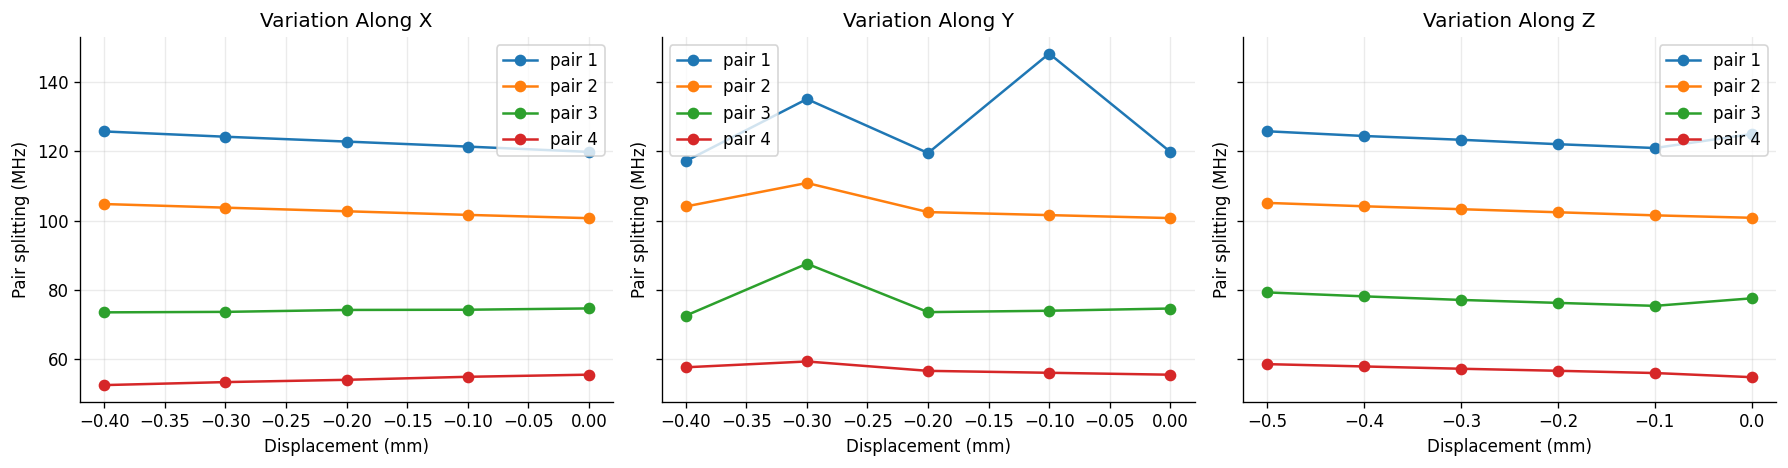

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax_plot, (variation, lab_axis) in zip(axes, VARIATION_TO_AXIS.items()):
    sub = pairs_long[pairs_long["variation"] == variation]

    for pair_id in sorted(sub["pair_id"].unique()):
        d = sub[sub["pair_id"] == pair_id].sort_values("offset_mm")
        ax_plot.plot(d["offset_mm"], d["splitting_MHz"], marker="o", label=f"pair {pair_id}")

    ax_plot.set_title(f"{variation}")
    ax_plot.set_xlabel("Displacement (mm)")
    ax_plot.set_ylabel("Pair splitting (MHz)")
    ax_plot.legend()

plt.tight_layout()
plt.show()

## Local linear-fit helper

In [104]:
def fit_splitting_slope(df_axis_pair: pd.DataFrame, max_abs_offset_mm=None) -> dict:
    d = df_axis_pair.sort_values("offset_mm").copy()

    if max_abs_offset_mm is not None:
        d = d[np.abs(d["offset_mm"]) <= max_abs_offset_mm].copy()

    x = d["offset_mm"].to_numpy(dtype=float)
    y = d["splitting_MHz"].to_numpy(dtype=float)

    fit = linregress(x, y)

    return {
        "n_points": len(d),
        "offset_min_mm": float(np.min(x)),
        "offset_max_mm": float(np.max(x)),
        "slope_MHz_per_mm": float(fit.slope),
        "intercept_MHz": float(fit.intercept),
        "r_value": float(fit.rvalue),
        "r_squared": float(fit.rvalue**2),
        "p_value": float(fit.pvalue),
        "slope_stderr": float(fit.stderr),
        "intercept_stderr": float(getattr(fit, "intercept_stderr", np.nan)),
    }

## Diagnose nonlinearity explicitly

In [105]:
diagnostic_rows = []

for variation, lab_axis in VARIATION_TO_AXIS.items():
    sub_var = pairs_long[pairs_long["variation"] == variation]

    for pair_id in sorted(sub_var["pair_id"].unique()):
        sub_pair = sub_var[sub_var["pair_id"] == pair_id]

        fit_full = fit_splitting_slope(sub_pair, max_abs_offset_mm=None)
        fit_local = fit_splitting_slope(sub_pair, max_abs_offset_mm=0.20)

        diagnostic_rows.append({
            "variation": variation,
            "lab_axis": lab_axis,
            "pair_id": pair_id,
            "full_slope_MHz_per_mm": fit_full["slope_MHz_per_mm"],
            "full_r2": fit_full["r_squared"],
            "full_n_points": fit_full["n_points"],
            "local_slope_MHz_per_mm": fit_local["slope_MHz_per_mm"],
            "local_r2": fit_local["r_squared"],
            "local_n_points": fit_local["n_points"],
        })

diagnostic_df = pd.DataFrame(diagnostic_rows).sort_values(["pair_id", "lab_axis"]).reset_index(drop=True)
display(diagnostic_df)

,variation,lab_axis,pair_id,full_slope_MHz_per_mm,full_r2,full_n_points,local_slope_MHz_per_mm,local_r2,local_n_points
0,Variation Along X,x,1,-14.649236,0.999764,5,-14.894365,0.999751,3
1,Variation Along Y,y,1,18.487918,0.047839,5,1.713941,0.000108,3
2,Variation Along Z,z,1,-4.474249,0.208074,6,14.672141,0.494782,3
3,Variation Along X,x,2,-10.238419,0.999648,5,-9.956530,0.999183,3
4,Variation Along Y,y,2,-15.983050,0.387306,5,-8.654121,0.999975,3
5,Variation Along Z,z,2,-8.639640,0.998299,6,-7.972242,0.995463,3
6,Variation Along X,x,3,2.881705,0.950951,5,2.191352,0.855702,3
7,Variation Along Y,y,3,-9.463311,0.057388,5,5.190449,0.981851,3
8,Variation Along Z,z,3,-5.030490,0.468784,6,6.596687,0.362178,3
9,Variation Along X,x,4,7.541552,0.996948,5,7.417044,0.990263,3


## Overlay linear slope


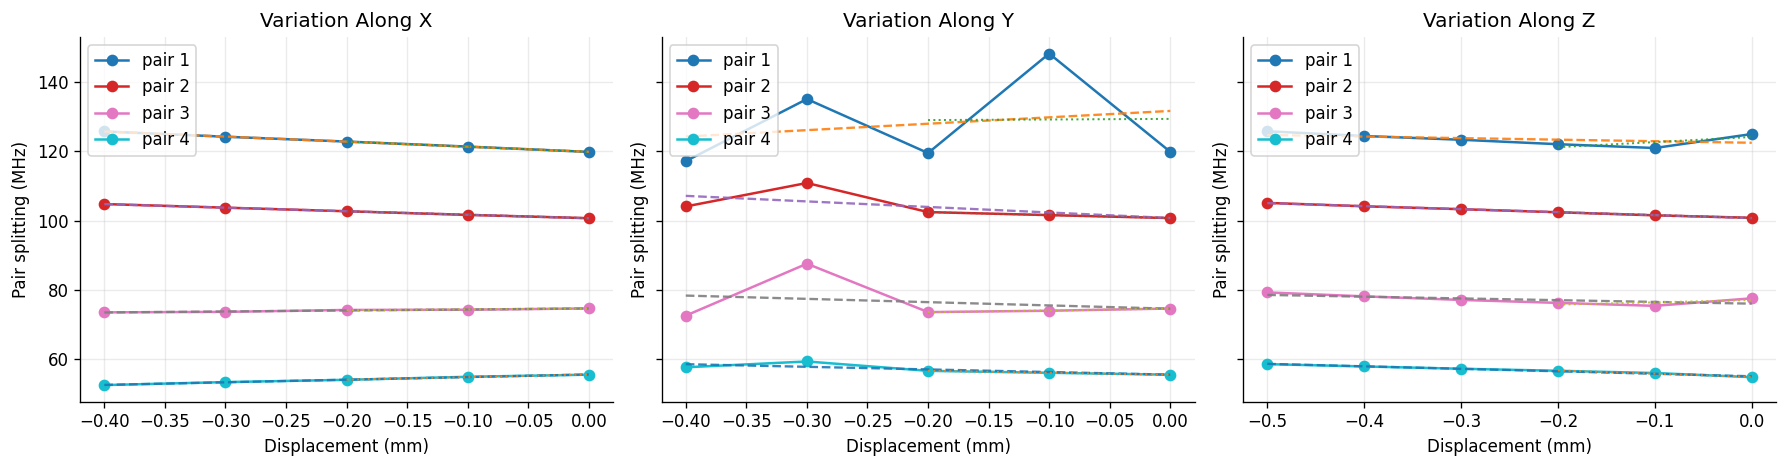

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax_plot, (variation, lab_axis) in zip(axes, VARIATION_TO_AXIS.items()):
    sub = pairs_long[pairs_long["variation"] == variation]

    for pair_id in sorted(sub["pair_id"].unique()):
        d = sub[sub["pair_id"] == pair_id].sort_values("offset_mm")
        ax_plot.plot(d["offset_mm"], d["splitting_MHz"], marker="o", label=f"pair {pair_id}")

        # full-range fit used for the response matrix
        fit_full = fit_splitting_slope(d, max_abs_offset_mm=None)
        xx_full = np.linspace(d["offset_mm"].min(), d["offset_mm"].max(), 100)
        yy_full = fit_full["intercept_MHz"] + fit_full["slope_MHz_per_mm"] * xx_full
        ax_plot.plot(xx_full, yy_full, linestyle="--", linewidth=1.4, alpha=0.9)

        # optional local fit near 0 for diagnosis only
        dloc = d[np.abs(d["offset_mm"]) <= 0.20].copy()
        if len(dloc) >= 2:
            fit_loc = fit_splitting_slope(dloc, max_abs_offset_mm=None)
            xx_loc = np.linspace(dloc["offset_mm"].min(), dloc["offset_mm"].max(), 50)
            yy_loc = fit_loc["intercept_MHz"] + fit_loc["slope_MHz_per_mm"] * xx_loc
            ax_plot.plot(xx_loc, yy_loc, linestyle=":", linewidth=1.2, alpha=0.9)

    ax_plot.set_title(f"{variation}")
    ax_plot.set_xlabel("Displacement (mm)")
    ax_plot.set_ylabel("Pair splitting (MHz)")
    ax_plot.legend()

plt.tight_layout()
plt.show()

## Build the local response matrix

In [107]:
slope_rows = []

for variation, lab_axis in VARIATION_TO_AXIS.items():
    sub_var = pairs_long[pairs_long["variation"] == variation]

    for pair_id in sorted(sub_var["pair_id"].unique()):
        sub_pair = sub_var[sub_var["pair_id"] == pair_id]

        # full-range slope is the main input to the response matrix
        fit_res = fit_splitting_slope(sub_pair, max_abs_offset_mm=None)

        slope_rows.append({
            "variation": variation,
            "lab_axis": lab_axis,
            "pair_id": pair_id,
            **fit_res,
        })

slopes_df = pd.DataFrame(slope_rows).sort_values(["pair_id", "lab_axis"]).reset_index(drop=True)
display(slopes_df)

,variation,lab_axis,pair_id,n_points,offset_min_mm,offset_max_mm,slope_MHz_per_mm,intercept_MHz,r_value,r_squared,p_value,slope_stderr,intercept_stderr
0,Variation Along X,x,1,5,-0.4,-0.0,-14.649236,119.863501,-0.999882,0.999764,0.000002,0.129953,0.031832
1,Variation Along Y,y,1,5,-0.4,-0.0,18.487918,131.661911,0.218721,0.047839,0.723753,47.620409,11.664570
2,Variation Along Z,z,1,6,-0.5,-0.0,-4.474249,122.472254,-0.456151,0.208074,0.363230,4.364396,1.321386
3,Variation Along X,x,2,5,-0.4,-0.0,-10.238419,100.670562,-0.999824,0.999648,0.000003,0.110948,0.027177
4,Variation Along Y,y,2,5,-0.4,-0.0,-15.983050,100.751215,-0.622339,0.387306,0.262246,11.606302,2.842952
5,Variation Along Z,z,2,6,-0.5,-0.0,-8.639640,100.724659,-0.999149,0.998299,0.000001,0.178314,0.053987
6,Variation Along X,x,3,5,-0.4,-0.0,2.881705,74.647545,0.975167,0.950951,0.004680,0.377856,0.092556
7,Variation Along Y,y,3,5,-0.4,-0.0,-9.463311,74.581214,-0.239557,0.057388,0.697929,22.143188,5.423951
8,Variation Along Z,z,3,6,-0.5,-0.0,-5.030490,76.038616,-0.684678,0.468784,0.133466,2.677501,0.810654
9,Variation Along X,x,4,5,-0.4,-0.0,7.541552,55.600516,0.998473,0.996948,0.000072,0.240908,0.059010


In [108]:
response_matrix = (
    slopes_df.pivot(index="pair_id", columns="lab_axis", values="slope_MHz_per_mm")
    .reindex(index=[1, 2, 3, 4], columns=["x", "y", "z"])
)

response_matrix_err = (
    slopes_df.pivot(index="pair_id", columns="lab_axis", values="slope_stderr")
    .reindex(index=[1, 2, 3, 4], columns=["x", "y", "z"])
)

print("Measured response matrix M_meas from full-range slopes [MHz/mm]:")
display(response_matrix)

print("Slope standard errors [MHz/mm]:")
display(response_matrix_err)

Measured response matrix M_meas from full-range slopes [MHz/mm]:


lab_axis,x,y,z
pair_id,,,
1,-14.649236,18.487918,-4.474249
2,-10.238419,-15.983050,-8.639640
3,2.881705,-9.463311,-5.030490
4,7.541552,-7.540334,-7.172519


Slope standard errors [MHz/mm]:


lab_axis,x,y,z
pair_id,,,
1,0.129953,47.620409,4.364396
2,0.110948,11.606302,0.178314
3,0.377856,22.143188,2.677501
4,0.240908,3.360402,0.457946


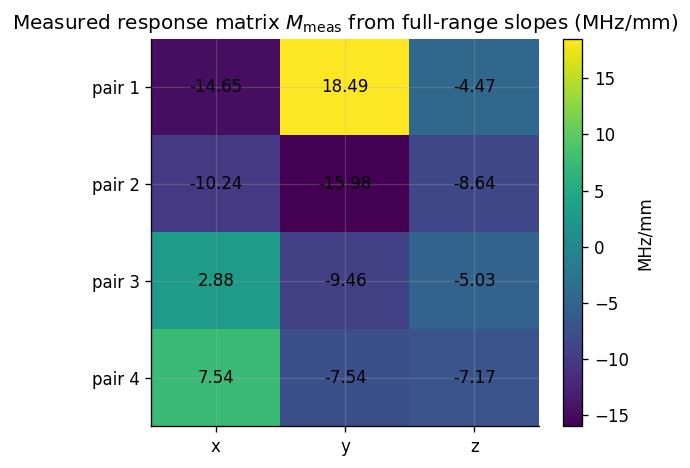

In [109]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(response_matrix.to_numpy(dtype=float), aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["x", "y", "z"])
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([f"pair {i}" for i in [1, 2, 3, 4]])
ax.set_title(r"Measured response matrix $M_{\mathrm{meas}}$ from full-range slopes (MHz/mm)")

for i in range(response_matrix.shape[0]):
    for j in range(response_matrix.shape[1]):
        val = response_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="MHz/mm")
plt.tight_layout()
plt.show()

## Geometric model for the [100]-cut diamond

For a [100]-cut diamond, the four NV axes are the tetrahedral ⟨111⟩ directions. In a canonical crystal-frame convention,
\[
\hat{\mathbf n}_1=
rac{1}{\sqrt3}(1,1,1),\quad
\hat{\mathbf n}_2=
rac{1}{\sqrt3}(1,-1,-1),
\]
\[
\hat{\mathbf n}_3=
rac{1}{\sqrt3}(-1,1,-1),\quad
\hat{\mathbf n}_4=
rac{1}{\sqrt3}(-1,-1,1).
\]

Because the sample is [100]-cut and the lab \(z\) axis is the optical axis / surface normal, the crystal [100] direction should align approximately with lab \(z\). We include that as a soft geometric constraint.

The fitted model is

\[
M_{\mathrm{model}}=\mathbf 1\,\mathbf b^	op + S\,P\,N_{\mathrm{lab}}\,G_{\mathrm{eff}},
\]

where \(\mathbf 1\,\mathbf b^	op\) is a common-mode column offset term.

In [110]:
# --- Diagnostic geometry preparation only ---
# We keep the known [100]-diamond NV axis set here,
# but we do not yet solve for a final rotation matrix from M_meas alone,
# because the previous exact-fit model was too flexible.

N_dia = (1 / np.sqrt(3)) * np.array([
    [ 1,  1,  1],   # d1
    [ 1, -1, -1],   # d2
    [-1,  1, -1],   # d3
    [-1, -1,  1],   # d4
], dtype=float)

N_dia_df = pd.DataFrame(N_dia, index=["d1", "d2", "d3", "d4"], columns=["x_dia", "y_dia", "z_dia"])
display(N_dia_df)

M_meas = response_matrix.to_numpy(dtype=float)
M_err = response_matrix_err.to_numpy(dtype=float)

print("M_meas shape:", M_meas.shape)
print("M_err shape:", M_err.shape)

# Column-centered matrix removes common-mode offsets explicitly
col_means = M_meas.mean(axis=0, keepdims=True)
M_centered = M_meas - col_means

print("Column means removed from M_meas:")
display(pd.DataFrame(col_means, index=["column_mean"], columns=["x", "y", "z"]))

print("Column-centered response matrix:")
display(pd.DataFrame(M_centered, index=[f"pair {i}" for i in range(1, 5)], columns=["x", "y", "z"]))

,x_dia,y_dia,z_dia
d1,0.57735,0.57735,0.57735
d2,0.57735,-0.57735,-0.57735
d3,-0.57735,0.57735,-0.57735
d4,-0.57735,-0.57735,0.57735


M_meas shape: (4, 3)
M_err shape: (4, 3)
Column means removed from M_meas:


,x,y,z
column_mean,-3.6161,-3.624694,-6.329225


Column-centered response matrix:


,x,y,z
pair 1,-11.033136,22.112612,1.854976
pair 2,-6.622319,-12.358356,-2.310415
pair 3,6.497804,-5.838617,1.298734
pair 4,11.157651,-3.915640,-0.843295


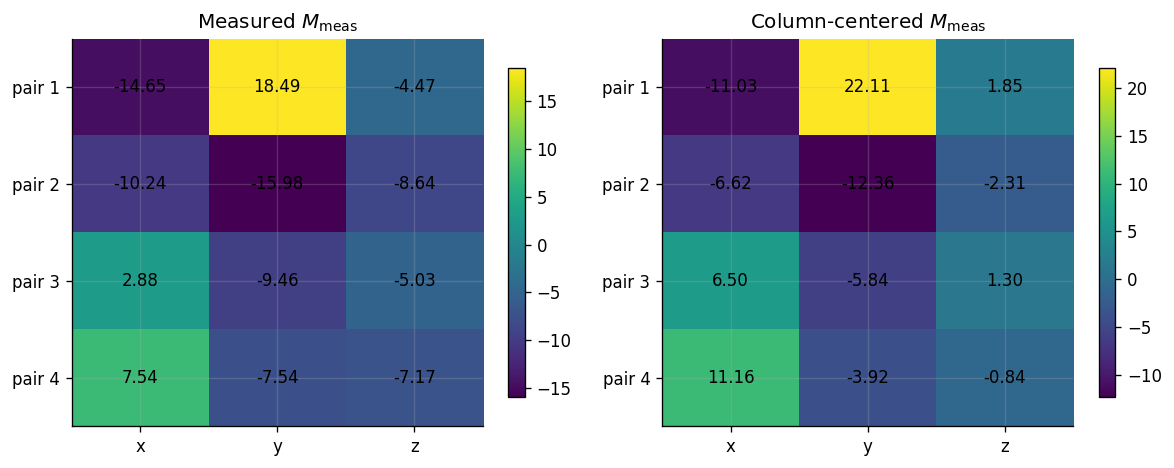

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, mat, title in zip(
    axes,
    [M_meas, M_centered],
    [r"Measured $M_{\mathrm{meas}}$", r"Column-centered $M_{\mathrm{meas}}$"]
):
    im = ax.imshow(mat, aspect="auto")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["x", "y", "z"])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels([f"pair {i}" for i in [1, 2, 3, 4]])
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
plt.show()

## Interpreting the measured and column-centered response matrices

The measured response matrix
\[
M_{\mathrm{meas}}
\]
contains the full-range linear slopes of the four measured dip-pair splittings with respect to lab-frame displacements along \(x\), \(y\), and \(z\).

The column-centered matrix
\[
M_{\mathrm{centered}} = M_{\mathrm{meas}} - \mathbf 1\,\bar{\mathbf m}^{\top}
\]
removes the common column means. This is useful because the pure tetrahedral NV-axis contribution has zero row-sum structure, while the measured response matrix can contain shared offsets from fitting or experimental systematics.

### What the two matrices tell us
- **\(M_{\mathrm{meas}}\)** is the experimentally direct object.
- **\(M_{\mathrm{centered}}\)** is the better object for the next geometric notebook, where we will compare the measured directional response against the rotated \(\langle111\rangle\) axis set of a [100]-cut diamond.

### Important caution
At this stage, we do **not** yet claim a final lab-to-diamond rotation matrix.  
The response matrix is trustworthy; a fully free geometric fit to it is not yet uniquely identifiable without stronger physical constraints on the field-gradient structure.

In [112]:
response_summary_df = pd.DataFrame({
    "pair_id": [1, 2, 3, 4],
    "mx_MHz_per_mm": M_meas[:, 0],
    "my_MHz_per_mm": M_meas[:, 1],
    "mz_MHz_per_mm": M_meas[:, 2],
    "mx_centered": M_centered[:, 0],
    "my_centered": M_centered[:, 1],
    "mz_centered": M_centered[:, 2],
})

response_summary_df["norm_meas"] = np.linalg.norm(M_meas, axis=1)
response_summary_df["norm_centered"] = np.linalg.norm(M_centered, axis=1)

display(response_summary_df)

,pair_id,mx_MHz_per_mm,my_MHz_per_mm,mz_MHz_per_mm,mx_centered,my_centered,mz_centered,norm_meas,norm_centered
0,1,-14.649236,18.487918,-4.474249,-11.033136,22.112612,1.854976,24.008793,24.781821
1,2,-10.238419,-15.983050,-8.639640,-6.622319,-12.358356,-2.310415,20.854891,14.209929
2,3,2.881705,-9.463311,-5.030490,6.497804,-5.838617,1.298734,11.097942,8.831626
3,4,7.541552,-7.540334,-7.172519,11.157651,-3.915640,-0.843295,12.852107,11.854812


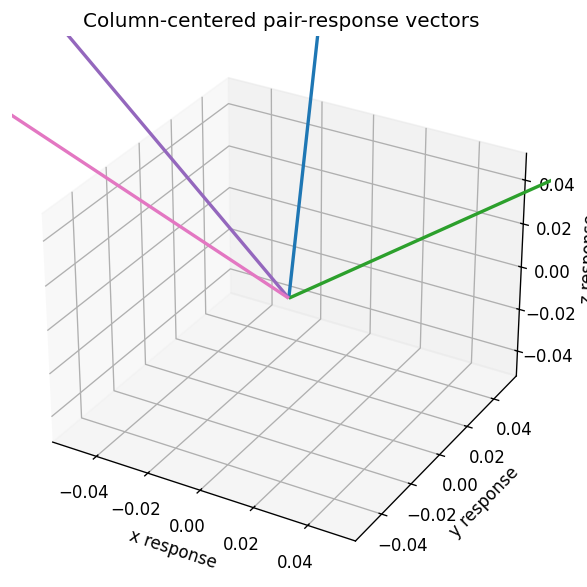

In [113]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

colors = ["tab:blue", "tab:green", "tab:purple", "tab:pink"]

for i, color in zip(range(4), colors):
    vec = M_centered[i]
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=color, linewidth=2, arrow_length_ratio=0.08)
    ax.text(vec[0], vec[1], vec[2], f"pair {i+1}")

ax.set_xlabel("x response")
ax.set_ylabel("y response")
ax.set_zlabel("z response")
ax.set_title("Column-centered pair-response vectors")
plt.tight_layout()
plt.show()

## Geometric constraints from the [100]-cut diamond

We now add the geometric information that is known independently of the ODMR fit.

### Known constraint 1: surface normal
The sample is [100]-cut, and the lab \(z\) axis is the optical axis / surface normal. Therefore, the crystal [100] direction is aligned with lab \(z\).

### Known constraint 2: NV-axis structure
For a [100]-cut diamond, the four NV axes are the tetrahedral \(\langle 111\rangle\) directions. In the lab frame, this implies:
- all four axes have the same angle to the surface normal,
- exactly **two NV axes have positive \(z\)-projection**,
- exactly **two NV axes have negative \(z\)-projection**.

So we should not allow an arbitrary 3D rotation of the tetrahedron. Once the surface normal is fixed, the remaining geometric freedom is mainly a rotation by an azimuthal angle \(\phi\) around lab \(z\). 

### Response model used here
We compare the column-centered measured response matrix
\[
M_{\mathrm{centered}}
\]
to the constrained model
\[
M_{\mathrm{centered}} \approx S\,P\,N_{\mathrm{lab}}(\phi)\,G,
\]
where:
- \(N_{\mathrm{lab}}(\phi)\) is the [100]-constrained NV-axis set rotated about lab \(z\),
- \(P\) is a permutation assigning measured dip pairs to crystal axes,
- \(S\) is a sign matrix accounting for splitting-sign conventions,
- \(G\) is a **symmetric traceless** \(3\times3\) effective gradient tensor.

This is much more physically constrained than the earlier fully free model.

In [114]:
from itertools import permutations, product

# [100]-constrained NV axis template in the lab frame:
# two axes above the xy-plane, two below, all at the tetrahedral angle.
a = np.sqrt(2/3)
b = 1/np.sqrt(3)

N100_base = np.array([
    [ a,  0,  b],   # above
    [-a,  0,  b],   # above
    [ 0,  a, -b],   # below
    [ 0, -a, -b],   # below
], dtype=float)

display(pd.DataFrame(N100_base, index=["n1", "n2", "n3", "n4"], columns=["lab_x", "lab_y", "lab_z"]))

,lab_x,lab_y,lab_z
n1,0.816497,0.000000,0.57735
n2,-0.816497,0.000000,0.57735
n3,0.000000,0.816497,-0.57735
n4,0.000000,-0.816497,-0.57735


## Parameterization of the remaining geometric freedom

Because the [100] surface normal is already fixed to lab \(z\), the main remaining geometric degree of freedom is an in-plane rotation
\[
\phi
\]
around lab \(z\).

We therefore generate candidate NV-axis sets of the form
\[
N_{\mathrm{lab}}(\phi)=N_{100,\mathrm{base}}\,R_z(\phi)^\top,
\]
using row-vector convention.

## Symmetric traceless gradient model

Instead of allowing a completely free \(3\times 3\) effective gradient matrix, we impose the physically motivated structure:
- \(G = G^\top\) (symmetric),
- \(\mathrm{tr}(G)=0\) (traceless).

A convenient 5-parameter basis is:
\[
G = c_1 B_1 + c_2 B_2 + c_3 B_3 + c_4 B_4 + c_5 B_5,
\]
with basis matrices chosen to span all symmetric traceless \(3\times3\) matrices.

This reduces the flexibility of the model and makes the geometry fit meaningful.

In [115]:
def Rz(phi):
    c, s = np.cos(phi), np.sin(phi)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1],
    ], dtype=float)

def N_lab_from_phi(phi):
    return N100_base @ Rz(phi).T

In [116]:
B1 = np.array([[1, 0, 0],
               [0,-1, 0],
               [0, 0, 0]], dtype=float)

B2 = np.array([[1, 0, 0],
               [0, 1, 0],
               [0, 0,-2]], dtype=float)

B3 = np.array([[0, 1, 0],
               [1, 0, 0],
               [0, 0, 0]], dtype=float)

B4 = np.array([[0, 0, 1],
               [0, 0, 0],
               [1, 0, 0]], dtype=float)

B5 = np.array([[0, 0, 0],
               [0, 0, 1],
               [0, 1, 0]], dtype=float)

G_basis = [B1, B2, B3, B4, B5]

def build_perm_matrix(perm):
    P = np.zeros((4, 4), dtype=float)
    for i, j in enumerate(perm):
        P[i, j] = 1.0
    return P

def build_sign_matrix(signs):
    return np.diag(np.asarray(signs, dtype=float))

In [117]:
def fit_symmetric_traceless_G(Ncand, Mtarget):
    """
    Solve Mtarget ≈ Ncand @ G
    with G = sum_k c_k B_k, symmetric traceless.
    """
    design_cols = []
    for B in G_basis:
        design_cols.append((Ncand @ B).reshape(-1, order="C"))

    A = np.column_stack(design_cols)  # shape (12, 5)
    y = Mtarget.reshape(-1, order="C")

    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)

    G = np.zeros((3, 3), dtype=float)
    for c, B in zip(coeffs, G_basis):
        G += c * B

    Mmodel = Ncand @ G
    return coeffs, G, Mmodel

## Candidate search

We now evaluate:
- a grid of azimuth angles \(\phi\),
- all 24 pair-to-axis permutations,
- all 16 sign conventions.

For each candidate:
1. construct the constrained NV-axis matrix,
2. fit the best symmetric traceless gradient tensor,
3. compute the weighted residual to the column-centered response matrix.

The goal is not yet to reconstruct the magnetic field itself, but to identify which pair-to-axis assignments and azimuths are most consistent with the measured directional response.

In [118]:
M_target = M_centered.copy()

# Use the same uncertainty matrix as before for weighting
M_sigma = response_matrix_err.to_numpy(dtype=float)
sigma_floor = np.nanmedian(M_sigma[np.isfinite(M_sigma)])
if not np.isfinite(sigma_floor) or sigma_floor <= 0:
    sigma_floor = 1.0
M_sigma_safe = np.where(np.isfinite(M_sigma) & (M_sigma > 0), M_sigma, sigma_floor)

phi_grid_deg = np.linspace(0, 180, 721)   # 0.25 degree steps
phi_grid_rad = np.deg2rad(phi_grid_deg)

candidate_rows = []

all_perms = list(permutations(range(4)))
all_signs = list(product([-1, 1], repeat=4))

print(f"Testing {len(phi_grid_deg)} azimuths × {len(all_perms)} permutations × {len(all_signs)} sign patterns")

for phi_deg, phi in zip(phi_grid_deg, phi_grid_rad):
    Nlab = N_lab_from_phi(phi)

    for perm in all_perms:
        P = build_perm_matrix(perm)

        for signs in all_signs:
            S = build_sign_matrix(signs)
            Ncand = S @ P @ Nlab

            coeffs, Gfit, Mmodel = fit_symmetric_traceless_G(Ncand, M_target)

            resid = (M_target - Mmodel) / M_sigma_safe
            chi2 = float(np.sum(resid**2))
            rms = float(np.sqrt(np.mean((M_target - Mmodel)**2)))

            candidate_rows.append({
                "phi_deg": float(phi_deg),
                "perm": perm,
                "signs": signs,
                "chi2": chi2,
                "rms_MHz_per_mm": rms,
                "Ncand": Ncand,
                "Gfit": Gfit,
                "Mmodel": Mmodel,
            })

print(f"Finished {len(candidate_rows)} constrained candidates")

Testing 721 azimuths × 24 permutations × 16 sign patterns
Finished 276864 constrained candidates


In [119]:
ranked_geom_df = pd.DataFrame([
    {
        "candidate_idx": i,
        "phi_deg": row["phi_deg"],
        "perm": row["perm"],
        "signs": row["signs"],
        "chi2": row["chi2"],
        "rms_MHz_per_mm": row["rms_MHz_per_mm"],
    }
    for i, row in enumerate(candidate_rows)
]).sort_values(["chi2", "rms_MHz_per_mm"]).reset_index(drop=True)

ranked_geom_df.insert(0, "rank", np.arange(1, len(ranked_geom_df) + 1))
display(ranked_geom_df.head(15))

,rank,candidate_idx,phi_deg,perm,signs,chi2,rms_MHz_per_mm
0,1,173312,112.75,"(1, 2, 0, 3)","(-1, -1, -1, -1)",1024.834352,3.702780
1,2,173327,112.75,"(1, 2, 0, 3)","(1, 1, 1, 1)",1024.834352,3.702780
2,3,35152,22.75,"(2, 0, 3, 1)","(-1, -1, -1, -1)",1024.834352,3.702780
3,4,35167,22.75,"(2, 0, 3, 1)","(1, 1, 1, 1)",1024.834352,3.702780
4,5,35536,23.00,"(2, 0, 3, 1)","(-1, -1, -1, -1)",1024.856004,3.701095
5,6,35551,23.00,"(2, 0, 3, 1)","(1, 1, 1, 1)",1024.856004,3.701095
6,7,173696,113.00,"(1, 2, 0, 3)","(-1, -1, -1, -1)",1024.856004,3.701095
7,8,173711,113.00,"(1, 2, 0, 3)","(1, 1, 1, 1)",1024.856004,3.701095
8,9,34768,22.50,"(2, 0, 3, 1)","(-1, -1, -1, -1)",1024.891399,3.704472
9,10,34783,22.50,"(2, 0, 3, 1)","(1, 1, 1, 1)",1024.891399,3.704472


In [120]:
axis_labels = ["d1", "d2", "d3", "d4"]

decoded_rows = []
for _, row in ranked_geom_df.head(10).iterrows():
    perm = row["perm"]
    decoded_rows.append({
        "rank": row["rank"],
        "phi_deg": row["phi_deg"],
        "chi2": row["chi2"],
        "rms_MHz_per_mm": row["rms_MHz_per_mm"],
        "pair_1": axis_labels[perm[0]],
        "pair_2": axis_labels[perm[1]],
        "pair_3": axis_labels[perm[2]],
        "pair_4": axis_labels[perm[3]],
        "signs": row["signs"],
    })

decoded_geom_df = pd.DataFrame(decoded_rows)
display(decoded_geom_df)

,rank,phi_deg,chi2,rms_MHz_per_mm,pair_1,pair_2,pair_3,pair_4,signs
0,1,112.75,1024.834352,3.702780,d2,d3,d1,d4,"(-1, -1, -1, -1)"
1,2,112.75,1024.834352,3.702780,d2,d3,d1,d4,"(1, 1, 1, 1)"
2,3,22.75,1024.834352,3.702780,d3,d1,d4,d2,"(-1, -1, -1, -1)"
3,4,22.75,1024.834352,3.702780,d3,d1,d4,d2,"(1, 1, 1, 1)"
4,5,23.00,1024.856004,3.701095,d3,d1,d4,d2,"(-1, -1, -1, -1)"
5,6,23.00,1024.856004,3.701095,d3,d1,d4,d2,"(1, 1, 1, 1)"
6,7,113.00,1024.856004,3.701095,d2,d3,d1,d4,"(-1, -1, -1, -1)"
7,8,113.00,1024.856004,3.701095,d2,d3,d1,d4,"(1, 1, 1, 1)"
8,9,22.50,1024.891399,3.704472,d3,d1,d4,d2,"(-1, -1, -1, -1)"
9,10,22.50,1024.891399,3.704472,d3,d1,d4,d2,"(1, 1, 1, 1)"


In [121]:
best_geom_row = ranked_geom_df.iloc[0]
best_geom = candidate_rows[int(best_geom_row["candidate_idx"])]

phi_best_deg = best_geom["phi_deg"]
Ncand_best = best_geom["Ncand"]
G_best = best_geom["Gfit"]
Mmodel_best = best_geom["Mmodel"]
Mresid_best = M_target - Mmodel_best

print("Best constrained azimuth phi [deg]:", phi_best_deg)
print("Best permutation:", best_geom["perm"])
print("Best signs:", best_geom["signs"])
print("Best chi2:", best_geom["chi2"])
print("Best RMS [MHz/mm]:", best_geom["rms_MHz_per_mm"])

print("\nBest constrained NV axes in measured-pair order:")
display(pd.DataFrame(
    Ncand_best,
    index=[f"pair {i}" for i in range(1, 5)],
    columns=["lab_x", "lab_y", "lab_z"]
))

print("\nBest symmetric traceless gradient tensor:")
display(pd.DataFrame(
    G_best,
    index=["lab_x", "lab_y", "lab_z"],
    columns=["disp_x", "disp_y", "disp_z"]
))

Best constrained azimuth phi [deg]: 112.75
Best permutation: (1, 2, 0, 3)
Best signs: (-1, -1, -1, -1)
Best chi2: 1024.8343518202312
Best RMS [MHz/mm]: 3.7027798150521543

Best constrained NV axes in measured-pair order:


,lab_x,lab_y,lab_z
pair 1,-0.315748,0.752974,-0.57735
pair 2,0.752974,0.315748,0.57735
pair 3,0.315748,-0.752974,-0.57735
pair 4,-0.752974,-0.315748,0.57735



Best symmetric traceless gradient tensor:


,disp_x,disp_y,disp_z
lab_x,-7.611042,-12.748886,1.483730
lab_y,-12.748886,12.063908,-7.063499
lab_z,1.483730,-7.063499,-4.452866


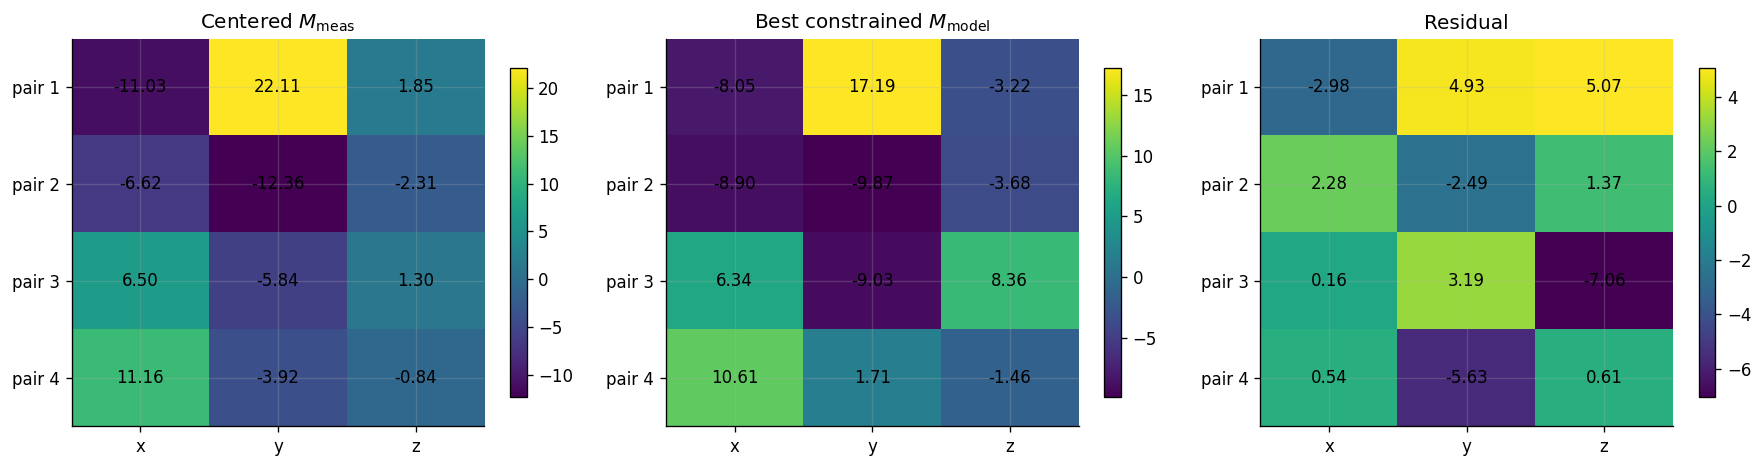

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mat, title in zip(
    axes,
    [M_target, Mmodel_best, Mresid_best],
    [r"Centered $M_{\mathrm{meas}}$", r"Best constrained $M_{\mathrm{model}}$", r"Residual"]
):
    im = ax.imshow(mat, aspect="auto")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["x", "y", "z"])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels([f"pair {i}" for i in [1, 2, 3, 4]])
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
plt.show()

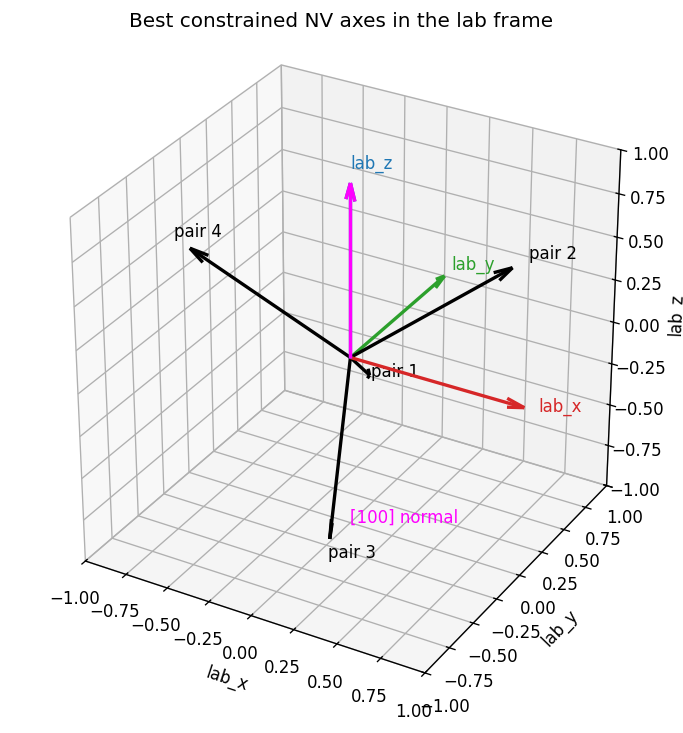

In [123]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# Lab axes
basis = np.eye(3)
basis_colors = ["tab:red", "tab:green", "tab:blue"]
basis_labels = ["lab_x", "lab_y", "lab_z"]

for vec, c, lbl in zip(basis, basis_colors, basis_labels):
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=c, linewidth=2, arrow_length_ratio=0.10)
    ax.text(vec[0]*1.08, vec[1]*1.08, vec[2]*1.08, lbl, color=c)

# Best constrained NV axes
for i, row in enumerate(Ncand_best, start=1):
    ax.quiver(0, 0, 0, row[0], row[1], row[2], color="black", linewidth=2, arrow_length_ratio=0.10)
    ax.text(row[0]*1.10, row[1]*1.10, row[2]*1.10, f"pair {i}")

# Show the [100] normal explicitly
ax.quiver(0, 0, 0, 0, 0, 1, color="magenta", linewidth=2, arrow_length_ratio=0.10)
ax.text(0, 0, -1.0, "[100] normal", color="magenta")

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_box_aspect((1, 1, 1))
ax.set_xlabel("lab_x")
ax.set_ylabel("lab_y")
ax.set_zlabel("lab_z")
ax.set_title("Best constrained NV axes in the lab frame")
plt.tight_layout()
plt.show()

In [124]:
OUTDIR = Path("./outputs")
OUTDIR.mkdir(exist_ok=True)

ranked_geom_df.to_csv(OUTDIR / "constrained_geometry_ranking.csv", index=False)
decoded_geom_df.to_csv(OUTDIR / "constrained_geometry_top10_decoded.csv", index=False)

pd.DataFrame(
    Ncand_best,
    index=[f"pair_{i}" for i in range(1, 5)],
    columns=["lab_x", "lab_y", "lab_z"]
).to_csv(OUTDIR / "best_constrained_nv_axes.csv")

pd.DataFrame(
    G_best,
    index=["lab_x", "lab_y", "lab_z"],
    columns=["disp_x", "disp_y", "disp_z"]
).to_csv(OUTDIR / "best_constrained_gradient_tensor.csv")

pd.DataFrame(
    Mmodel_best,
    index=[f"pair_{i}" for i in range(1, 5)],
    columns=["x", "y", "z"]
).to_csv(OUTDIR / "best_constrained_model_response.csv")

pd.DataFrame(
    Mresid_best,
    index=[f"pair_{i}" for i in range(1, 5)],
    columns=["x", "y", "z"]
).to_csv(OUTDIR / "best_constrained_response_residual.csv")

print(f"Saved constrained-geometry outputs in: {OUTDIR.resolve()}")

Saved constrained-geometry outputs in: /home/vita/projects/NV_sensing/nv_to_lab_frame/outputs
